Detect cloud bands in the South Pacific on 18 April 2016 using NASA IMERG data, and create a map showing the identification of the cloud bands.

In [1]:
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from cloudbandpy.load_driver import run_load_data

from cloudbandpy.cb_detection import detection_workflow
from cloudbandpy.figure_tools import show_blob_detection_process
from cloudbandpy.io_utilities import load_ymlfile, add_startend_datetime2config

Load configuration file and make adjustements for this test case

In [2]:
config_file = "../config/config_cbworkflow_southPacific_tb.yml"
config = load_ymlfile(config_file, isconfigfile=True)
config_event = config.copy()
# update datetime dates from config file
add_startend_datetime2config(config_event)
config_event["parameters_file"] = os.path.join(
    "../parameters/parameters_southhemisphere.yml"
)
# No need to save any files
config_event["save_dailyvar"] = False
config_event["save_listcloudbands"] = False
config["dir_figures"] = "./"

2023-11-28 17:22:31,913 - io_utilities.load_ymlfile - INFO: Configuration file loaded


Load ERA5 data and get its resolution, and load parameters file. The ERA5 file contains OLR data from 01.01.2016 to 30.05.2016.

In [3]:
tb2process, parameters, listofdates, lats, lons, resolution = run_load_data(config_event)

2023-11-28 17:22:31,921 - load_driver.run_load_data - INFO: Loading data and parameters 
2023-11-28 17:22:31,925 - io_utilities.load_ymlfile - INFO: Parameters file loaded
2023-11-28 17:22:31,926 - io_utilities.load_dataset - INFO: Loading dataset from /work/FAC/FGSE/IDYST/ddomeise/default/DATA/NASA_mergedIR/
2023-11-28 17:22:31,926 - io_utilities.load_dataset - INFO: Loading 2016 --> 2016
2023-11-28 17:23:10,540 - io_utilities.load_dataset - WARNING: latitudes are increasing. Must be decreasing. Reshapping latitudes and variable.
2023-11-28 17:23:18,643 - io_utilities.get_variable_lonlat_from_domain - INFO: Longitudes are going from -180 to 180 and domain is Pacific, or longitudes from 0 to 360 and domain is Atlantic: Mapping...
2023-11-28 17:23:18,644 - io_utilities.get_variable_lonlat_from_domain - INFO: Remapping
2023-11-28 17:23:30,205 - io_utilities.get_variable_lonlat_from_domain - INFO: Subsetting dataset on domain done
2023-11-28 17:23:30,258 - io_utilities.make_daily_average 

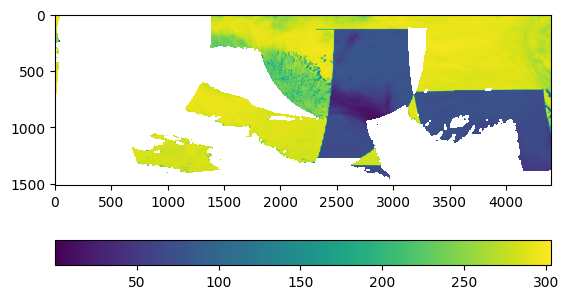

In [7]:
masked_tb = np.ma.masked_where(np.isnan(tb2process[0]), tb2process[0])
# masked_tb = np.ma.masked_where(np.isnan(tb2process[0]) | (tb2process[0] == 0), tb2process[0])

plt.imshow(masked_tb, cmap='viridis')
plt.colorbar(orientation="horizontal")
plt.show()

Run cloud band detection

In [5]:
(
        fill_binarize_data,
        dilation,
        labelled_blobs,
        labelled_candidates,
        cloud_bands_over_time,
        list_of_candidates,
        list_of_cloud_bands
    ) = detection_workflow(
        var2process=tb2process,
        parameters=parameters,
        latitudes=lats,
        longitudes=lons,
        resolution=resolution,
        listofdates=listofdates,
        config=config,
    )

2023-11-28 17:23:36,700 - cb_detection.detection_workflow - INFO: Cloud band detection in progress
2023-11-28 17:23:36,706 - cb_detection.blob_detection - WARNING: Some Missing Values in the Input
2023-11-28 17:23:58,630 - cb_detection.detection_workflow - INFO: Cloud band detection done


#### Create the series of maps which show the evolution of cloud bands over time

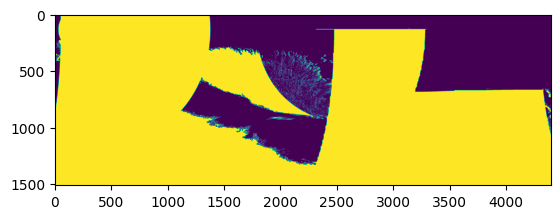

In [6]:
plt.imshow(fill_binarize_data[0])